<a href="https://colab.research.google.com/github/babycrashdev/m1_ia/blob/main/Projet_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet d'introduction a l'ia



## Configuration de l'environnement

In [1]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('⚠️ GPU non trouvé. Allez dans "Exécution" > "Modifier le type d\'exécution" et sélectionnez "T4 GPU".')
else:
  print('✅ GPU trouvé :', device_name)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
print("✅ Bibliothèques importées avec succès")

✅ GPU trouvé : /device:GPU:0
✅ Bibliothèques importées avec succès


In [2]:
import os
import pandas as pd

%cd /content

if not os.path.exists('ts-data-for-workload-classification'):
    !git clone https://github.com/phuongntmse/ts-data-for-workload-classification.git
    print("✅ Données téléchargées !")
else:
    print("📂 Les données sont déjà présentes.")

# Récupere les data
DATA_PATH = '/content/ts-data-for-workload-classification'

if os.path.exists(DATA_PATH):
    subfolders = [f for f in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, f)) and not f.startswith('.')]
    print(f"✅ Dossiers trouvés : {subfolders}")
else:
    print("❌ Erreur : Le dossier n'existe pas. Vérifiez le clonage.")



/content
Cloning into 'ts-data-for-workload-classification'...
remote: Enumerating objects: 1099, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 1099 (delta 2), reused 0 (delta 0), pack-reused 1093 (from 1)
Receiving objects: 100% (1099/1099), 54.13 MiB | 14.68 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (1051/1051), done.
✅ Données téléchargées !
✅ Dossiers trouvés : ['cpu-10', 'disk-2', 'cpu-19', 'cpu-12', 'disk-5', 'memory-3', 'cpu-17', 'cpu-16', 'disk-1', 'cpu-18', 'memory-4', 'cpu-8', 'cpu-1', 'disk-7', 'memory-2', 'memory-5', 'disk-9', 'cpu-11', 'cpu-2', 'cpu-9', 'cpu-3', 'cpu-15', 'disk-10', 'cpu-13', 'disk-3', 'cpu-4', 'cpu-20', 'disk-8', 'cpu-7', 'cpu-5', 'cpu-6', 'disk-6', 'disk-4', 'cpu-14', 'memory-1']


## Exploration et Préparation des Données



### Premiere visualisation

📝 Dimensions du fichier : (2154, 46)

📋 5 premières lignes :


,Timestamp,CpuALL_usage,Cpu0_usage,Cpu1_usage,Cpu2_usage,Cpu3_usage,Cpu4_usage,Cpu5_usage,Cpu6_usage,Cpu7_usage,...,Cpu34_usage,Cpu35_usage,cpu_frequency,memory_usage,Reads_on_sda,Writes_on_sda,Energy_usage_during_time,memory_usage_perce,write_rate_during_time,read_rate_during_time
0,1.760111e+09,12.75,2.28,9.18,11.22,20.28,1.08,14.61,12.65,6.71,...,10.43,5.6,2342,1938280,15552,105996,5471360.0,1.991452,2.0,0.0
1,1.760111e+09,12.75,2.28,9.18,11.22,20.28,1.08,14.61,12.65,6.71,...,10.43,5.6,2329,1936448,15552,105996,5207995.0,1.989569,0.0,0.0
2,1.760111e+09,12.75,2.28,9.18,11.22,20.28,1.08,14.61,12.65,6.71,...,10.43,5.6,2497,1937304,15552,105996,5260790.0,1.990449,0.0,0.0
3,1.760111e+09,12.75,2.28,9.18,11.22,20.28,1.08,14.61,12.65,6.71,...,10.43,5.6,2481,1936832,15552,105996,6673261.0,1.989964,0.0,0.0
4,1.760111e+09,12.75,2.28,9.18,11.22,20.28,1.08,14.61,12.65,6.71,...,10.43,5.6,2888,1936552,15552,105996,10759311.0,1.989676,0.0,0.0


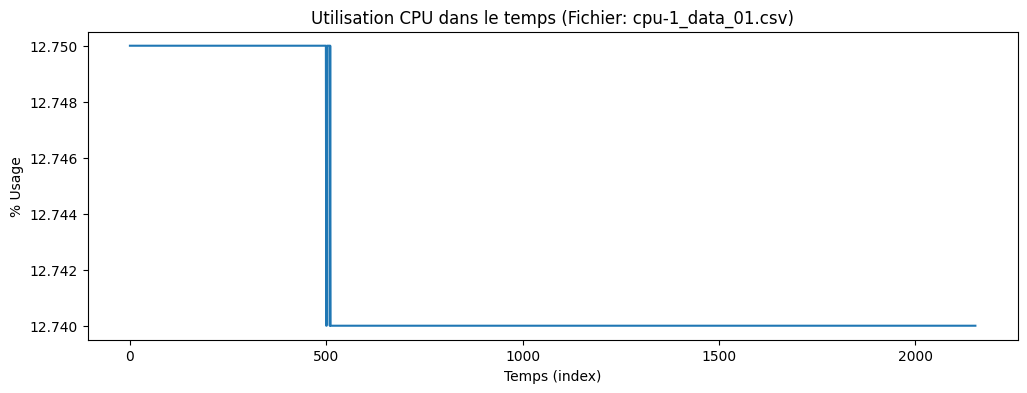

In [3]:
sample_file = os.path.join(DATA_PATH, 'cpu-1', 'cpu-1_data_01.csv')
df = pd.read_csv(sample_file)

print("📝 Dimensions du fichier :", df.shape)
print("\n📋 5 premières lignes :")
display(df.head())

plt.figure(figsize=(12, 4))
plt.plot(df['CpuALL_usage'])
plt.title('Utilisation CPU dans le temps (Fichier: cpu-1_data_01.csv)')
plt.xlabel('Temps (index)')
plt.ylabel('% Usage')
plt.show()


### Comparaison avec CPU, Disque, Mémoire

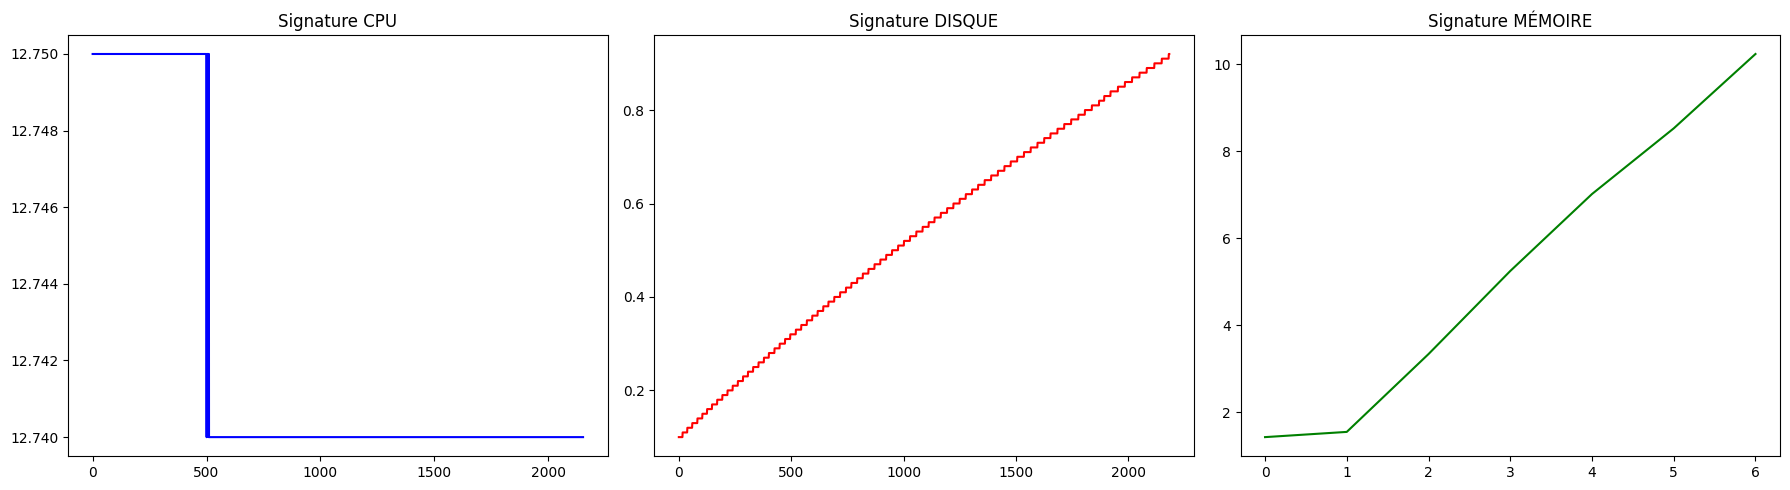

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. CPU
df_cpu = pd.read_csv(os.path.join(DATA_PATH, 'cpu-1/cpu-1_data_01.csv'))
axes[0].plot(df_cpu['CpuALL_usage'], color='blue')
axes[0].set_title('Signature CPU')

# 2. DISQUE
df_disk = pd.read_csv(os.path.join(DATA_PATH, 'disk-1/disk-1_data_01.csv'))
axes[1].plot(df_disk['CpuALL_usage'], color='red')
axes[1].set_title('Signature DISQUE')

# 3. MÉMOIRE
df_mem = pd.read_csv(os.path.join(DATA_PATH, 'memory-1/memory-1_data_01.csv'))
axes[2].plot(df_mem['CpuALL_usage'], color='green')
axes[2].set_title('Signature MÉMOIRE')

plt.tight_layout()
plt.show()



### Création du Dataset (Fenêtrage & Labels)


In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

WINDOW_SIZE = 50
FEATURES = ['CpuALL_usage', 'memory_usage_perce', 'read_rate_during_time', 'write_rate_during_time']
LABEL_MAP = {'cpu': 0, 'disk': 1, 'memory': 2}

scaler = MinMaxScaler()

def load_and_preprocess():
    all_sequences = []
    all_labels = []

    for cat_name, label_idx in LABEL_MAP.items():
        print(f"🔄 Traitement de la catégorie : {cat_name}...")

        cat_folders = [f for f in os.listdir(DATA_PATH) if f.startswith(cat_name) and os.path.isdir(os.path.join(DATA_PATH, f))]

        for folder in cat_folders:
            folder_path = os.path.join(DATA_PATH, folder)
            for file in os.listdir(folder_path):
                if file.endswith('.csv'):
                    file_path = os.path.join(folder_path, file)
                    df = pd.read_csv(file_path)
                    data = df[FEATURES].fillna(0).values
                    scaled_data = scaler.fit_transform(data)
                    for i in range(0, len(scaled_data) - WINDOW_SIZE, WINDOW_SIZE):
                        window = scaled_data[i : i + WINDOW_SIZE]
                        all_sequences.append(window)
                        all_labels.append(label_idx)

    return np.array(all_sequences), np.array(all_labels)

X, y = load_and_preprocess()

print(f"\n✅ Préparation terminée !")
print(f"📦 Forme de X (Données) : {X.shape} -> (Nombre de séquences, Longueur, Variables)")
print(f"🏷️ Forme de y (Labels)  : {y.shape}")


🔄 Traitement de la catégorie : cpu...
🔄 Traitement de la catégorie : disk...
🔄 Traitement de la catégorie : memory...

✅ Préparation terminée !
📦 Forme de X (Données) : (35928, 50, 4) -> (Nombre de séquences, Longueur, Variables)
🏷️ Forme de y (Labels)  : (35928,)


## Le modèle LSTM (Long Short-Term Memory)


In [6]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"📈 Données d'entraînement : {X_train.shape}")
print(f"📉 Données de test : {X_test.shape}")

model_lstm = Sequential([
    LSTM(64, input_shape=(WINDOW_SIZE, len(FEATURES))),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model_lstm.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

model_lstm.summary()

print("\n🚀 Lancement de l'entraînement...")
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)


📈 Données d'entraînement : (28742, 50, 4)
📉 Données de test : (7186, 50, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,843 (77.51 KB)

 Trainable params: 19,843 (77.51 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Lancement de l'entraînement...
Epoch 1/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8226 - loss: 0.4415 - val_accuracy: 0.8681 - val_loss: 0.3508
Epoch 2/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8584 - loss: 0.3662 - val_accuracy: 0.8652 - val_loss: 0.3587
Epoch 3/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8610 - loss: 0.3610 - val_accuracy: 0.8670 - val_loss: 0.3531
Epoch 4/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8374 - loss: 0.3896 - val_accuracy: 0.8249 - val_loss: 0.4022
Epoch 5/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8530 - loss: 0.3725 - val_accuracy: 0.8688 - val_loss: 0.3465
Epoch 6/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8627 - loss: 0.3584 - val_accuracy: 0.8782 - val_loss: 0.3318
Epoch 7/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8300 - loss: 0.3978 - val_accuracy: 0.8508 - val_loss: 0.3674
Epoch 8/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.837

### Courbe d'apprentissage (Loss & Accuracy)

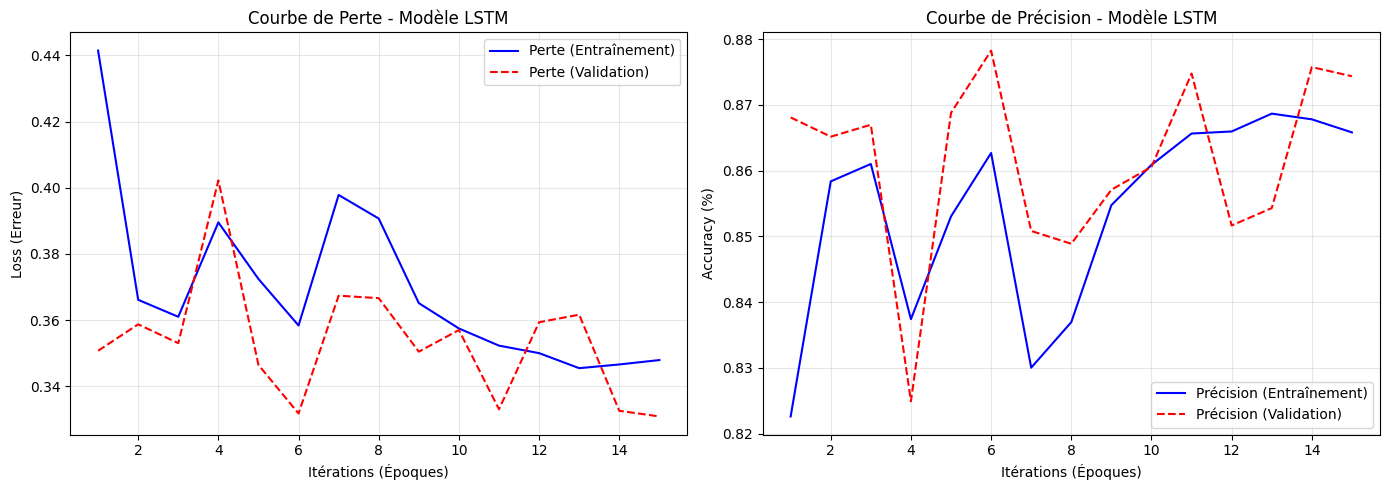

In [12]:
import matplotlib.pyplot as plt

def plot_learning_curves(history, model_name):
    history_dict = history.history

    loss_values = history_dict['loss']
    val_loss_values = history_dict['val_loss']
    acc_values = history_dict['accuracy']
    val_acc_values = history_dict['val_accuracy']
    epochs = range(1, len(loss_values) + 1)

    plt.figure(figsize=(14, 5))

    # Graphique 1 : La fonction Coût (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss_values, 'b-', label='Perte (Entraînement)')
    plt.plot(epochs, val_loss_values, 'r--', label='Perte (Validation)')
    plt.title(f'Courbe de Perte - {model_name}')
    plt.xlabel('Itérations (Époques)')
    plt.ylabel('Loss (Erreur)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Graphique 2 : La Précision (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc_values, 'b-', label='Précision (Entraînement)')
    plt.plot(epochs, val_acc_values, 'r--', label='Précision (Validation)')
    plt.title(f'Courbe de Précision - {model_name}')
    plt.xlabel('Itérations (Époques)')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_learning_curves(history_lstm, "Modèle LSTM")

### Matrice de confusion


225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


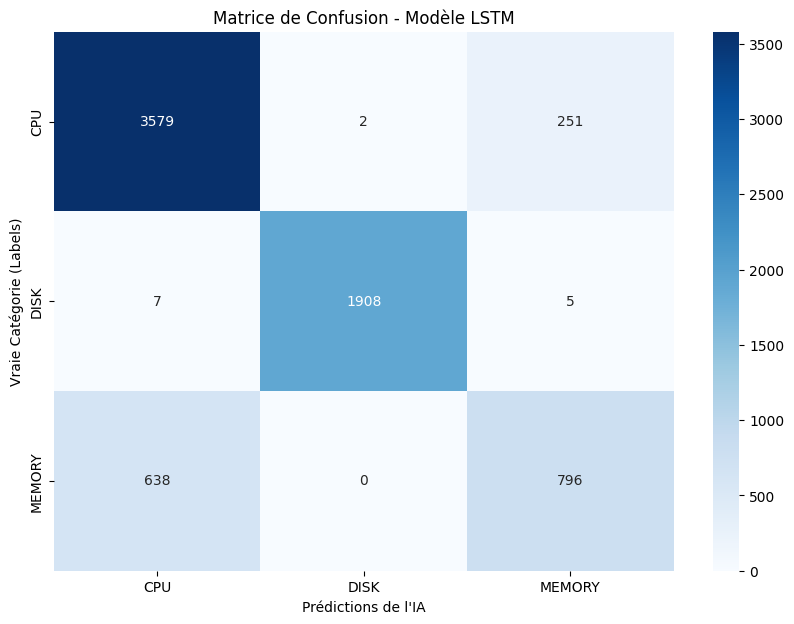


📋 Rapport de classification :
              precision    recall  f1-score   support

         CPU       0.85      0.93      0.89      3832
        DISK       1.00      0.99      1.00      1920
      MEMORY       0.76      0.56      0.64      1434

    accuracy                           0.87      7186
   macro avg       0.87      0.83      0.84      7186
weighted avg       0.87      0.87      0.87      7186



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_probs = model_lstm.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
categories = ['CPU', 'DISK', 'MEMORY']

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, cmap='Blues')
plt.xlabel('Prédictions de l\'IA')
plt.ylabel('Vraie Catégorie (Labels)')
plt.title('Matrice de Confusion - Modèle LSTM')
plt.show()

print("\n📋 Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=categories))


## Le Modele  CNN 1D (Convolutional Neural Network)


In [14]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

model_cnn = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(FEATURES))),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])


model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_cnn.summary()

print("\n🚀 Lancement de l'entraînement du CNN 1D...")
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 48, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 22, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        90,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,907 (452.76 KB)

 Trainable params: 115,907 (452.76 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Lancement de l'entraînement du CNN 1D...
Epoch 1/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8578 - loss: 0.3768 - val_accuracy: 0.8753 - val_loss: 0.3068
Epoch 2/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9044 - loss: 0.2755 - val_accuracy: 0.9095 - val_loss: 0.2450
Epoch 3/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9067 - loss: 0.2624 - val_accuracy: 0.9051 - val_loss: 0.2633
Epoch 4/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9090 - loss: 0.2528 - val_accuracy: 0.9148 - val_loss: 0.2267
Epoch 5/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9097 - loss: 0.2492 - val_accuracy: 0.9127 - val_loss: 0.2350
Epoch 6/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9104 - loss: 0.2456 - val_accuracy: 0.9157 - val_loss: 0.2236
Epoch 7/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9117 - loss: 0.2417 - val_accuracy: 0.9164 - val_loss: 0.2270
Epoch 8/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accur

### Courbe d'apprentissage (Loss & Accuracy)

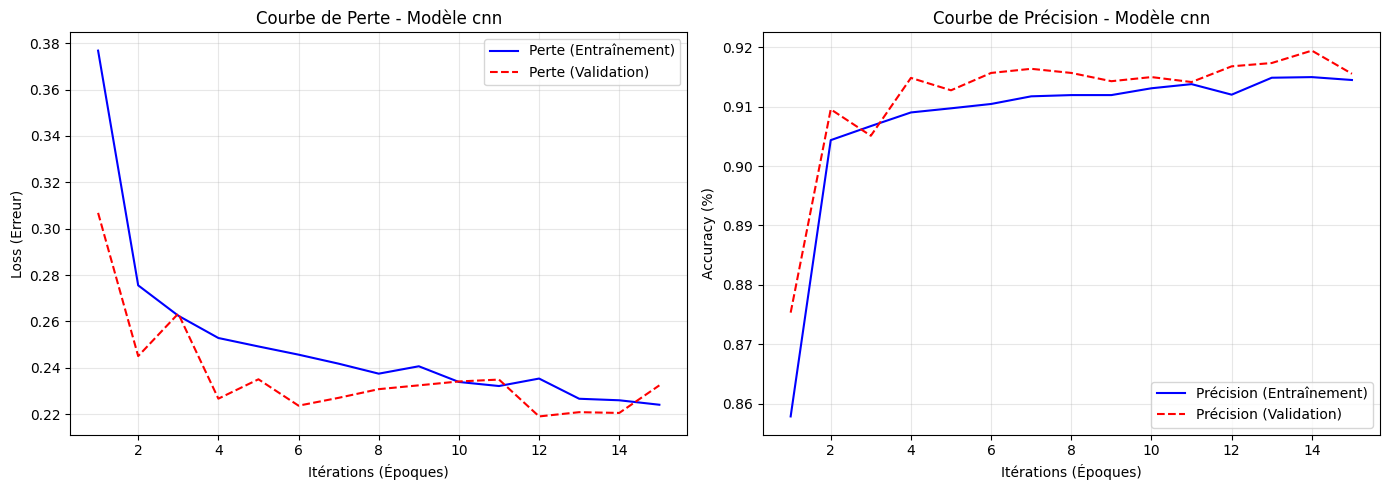

In [16]:
plot_learning_curves(history_cnn, "Modèle cnn")

### Matrice de confusion

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


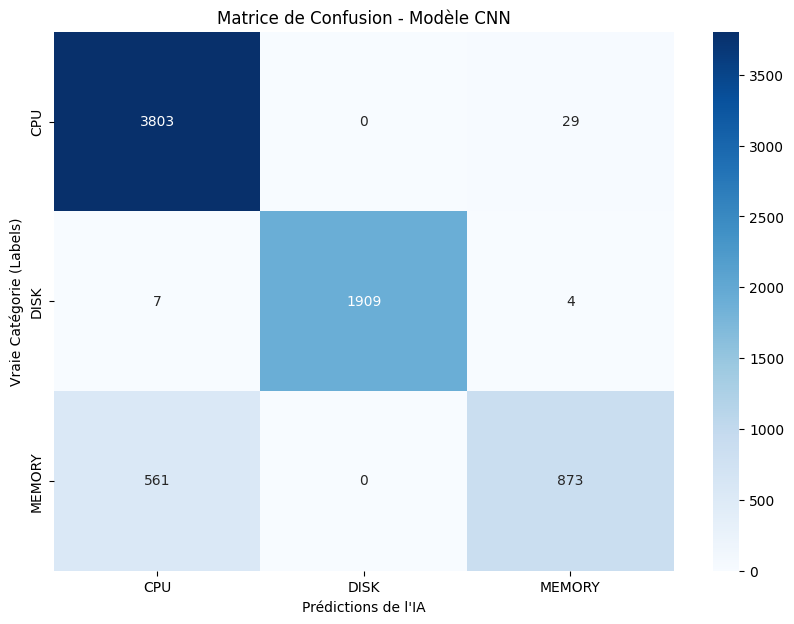


📋 Rapport de classification :
              precision    recall  f1-score   support

         CPU       0.87      0.99      0.93      3832
        DISK       1.00      0.99      1.00      1920
      MEMORY       0.96      0.61      0.75      1434

    accuracy                           0.92      7186
   macro avg       0.94      0.87      0.89      7186
weighted avg       0.92      0.92      0.91      7186



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_probs = model_cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
categories = ['CPU', 'DISK', 'MEMORY']

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, cmap='Blues')
plt.xlabel('Prédictions de l\'IA')
plt.ylabel('Vraie Catégorie (Labels)')
plt.title('Matrice de Confusion - Modèle CNN')
plt.show()

print("\n📋 Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=categories))


## Le Modele  Time Series Transformer

In [7]:
import tensorflow as tf
from tensorflow.keras import layers

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

inputs = layers.Input(shape=(WINDOW_SIZE, len(FEATURES)))

x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=64, dropout=0.1)
x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)

for dim in [64, 32]:
    x = layers.Dense(dim, activation="relu")(x)
    x = layers.Dropout(0.1)(x)

outputs = layers.Dense(3, activation="softmax")(x)

model_transformer = tf.keras.Model(inputs, outputs)

model_transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_transformer.summary()

print("\n🚀 Lancement de l'entraînement du Transformer...")
history_transformer = model_transformer.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 4)     │          8 │ input_layer_1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 4)     │      4,868 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 50, 4)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 4)     │          0 │ dropout_2[0][0],  │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 4)     │          8 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 50, 64)    │        320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 50, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 50, 4)     │        260 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 4)     │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 4)         │          0 │ add_1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 3)         │         99 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,963 (31.11 KB)

 Trainable params: 7,963 (31.11 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Lancement de l'entraînement du Transformer...
Epoch 1/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.8174 - loss: 0.4452 - val_accuracy: 0.8613 - val_loss: 0.3419
Epoch 2/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8647 - loss: 0.3522 - val_accuracy: 0.8923 - val_loss: 0.3052
Epoch 3/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8836 - loss: 0.3251 - val_accuracy: 0.8835 - val_loss: 0.3268
Epoch 4/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8910 - loss: 0.3117 - val_accuracy: 0.8959 - val_loss: 0.2896
Epoch 5/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8940 - loss: 0.3035 - val_accuracy: 0.9006 - val_loss: 0.2794
Epoch 6/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8922 - loss: 0.3062 - val_accuracy: 0.9009 - val_loss: 0.2768
Epoch 7/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8972 - loss: 0.2973 - val_accuracy: 0.9020 - val_loss: 0.2765
Epoch 8/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step 

### Courbe d'apprentissage (Loss & Accuracy)

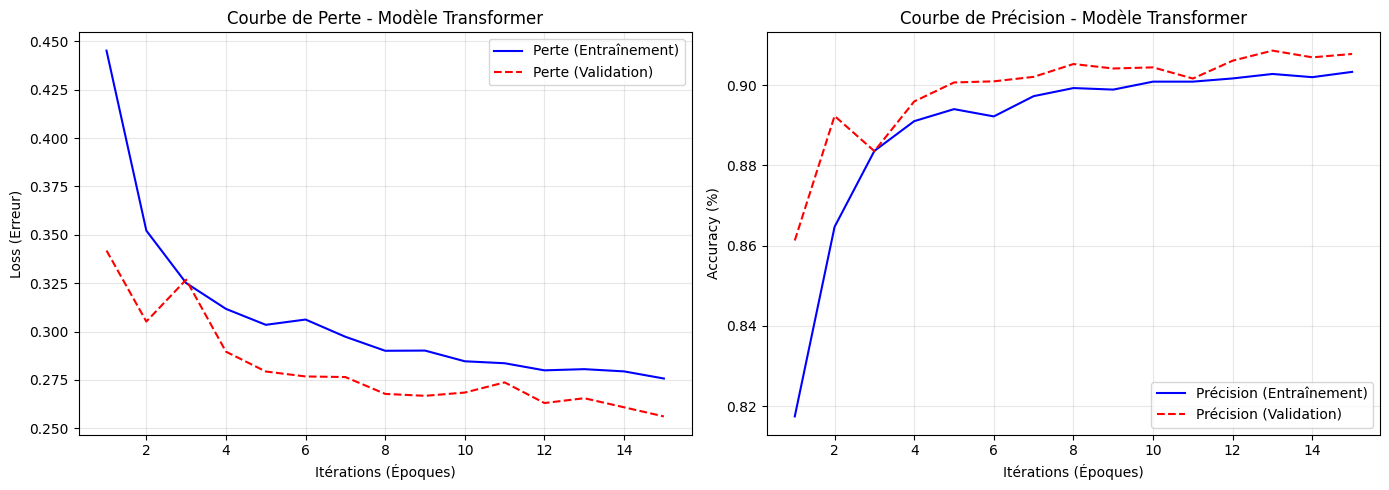

In [15]:
plot_learning_curves(history_transformer, "Modèle Transformer")

### Matrice de Confusion

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


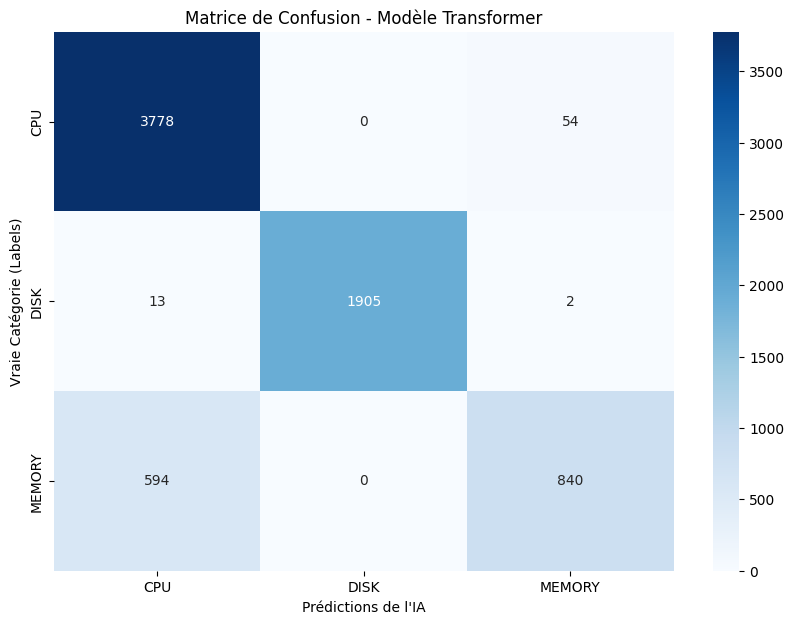


📋 Rapport de classification :
              precision    recall  f1-score   support

         CPU       0.86      0.99      0.92      3832
        DISK       1.00      0.99      1.00      1920
      MEMORY       0.94      0.59      0.72      1434

    accuracy                           0.91      7186
   macro avg       0.93      0.85      0.88      7186
weighted avg       0.91      0.91      0.90      7186



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_probs = model_transformer.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
categories = ['CPU', 'DISK', 'MEMORY']

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, cmap='Blues')
plt.xlabel('Prédictions de l\'IA')
plt.ylabel('Vraie Catégorie (Labels)')
plt.title('Matrice de Confusion - Modèle Transformer')
plt.show()

print("\n📋 Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=categories))